<a href="https://colab.research.google.com/github/roniarosariosamk/Student-Performance-Prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/bi.csv', encoding='latin1')
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()

Shape: (77, 11)
Missing values: 2
Duplicate rows: 0


,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [ ]:
df.columns = [c.strip().lower().replace(' ', '_').replace('/', '_') for c in df.columns]

subjects = ['python', 'db']
df['average_score'] = df[subjects].mean(axis=1).round(1)

# Assumption: a student passes if they score at least 40 in every subject
df['result'] = np.where((df[subjects] >= 40).all(axis=1), 'Pass', 'Fail')

print(df[subjects + ['average_score']].describe().round(1))
print("Pass rate (%):", round((df['result'] == 'Pass').mean() * 100, 1))

       python     db  average_score
count    75.0   77.0           77.0
mean     75.9   69.5           72.4
std      15.4   17.0           14.0
min      15.0   30.0           31.5
25%      71.0   56.0           65.0
50%      81.0   71.0           74.0
75%      85.0   83.0           84.0
max      91.0  100.0           93.0
Pass rate (%): 90.9


In [ ]:
for col in ['gender', 'country', 'residence', 'preveducation']:
    print(f"\nAverage score by {col}")
    print(df.groupby(col)['average_score'].mean().round(1).sort_values(ascending=False))

print("\nPass rate (%) by prevEducation")
print(df.groupby('preveducation')['result'].apply(lambda s: round((s == 'Pass').mean() * 100, 1)))


Average score by gender
gender
male      92.0
Male      74.8
female    73.5
Female    70.8
M         67.5
F         44.0
Name: average_score, dtype: float64

Average score by country
country
South Africa    85.5
Denmark         85.0
UK              83.5
Germany         80.3
Somali          76.2
Norge           73.5
norway          72.5
Kenya           72.5
Norway          72.4
Netherlands     72.0
Uganda          71.2
Italy           68.8
Spain           68.8
Nigeria         64.2
France          58.0
Rsa             44.0
Name: average_score, dtype: float64

Average score by residence
residence
BI_Residence    86.5
BI-Residence    85.5
Sognsvann       74.3
Private         72.8
BIResidence     72.5
BI Residence    70.3
Name: average_score, dtype: float64

Average score by preveducation
preveducation
DIPLOMA         92.0
Masters         79.1
Bachelors       75.6
Diplomaaa       73.0
Doctorate       72.7
Barrrchelors    72.5
diploma         67.5
Diploma         66.9
High School     64.7
H

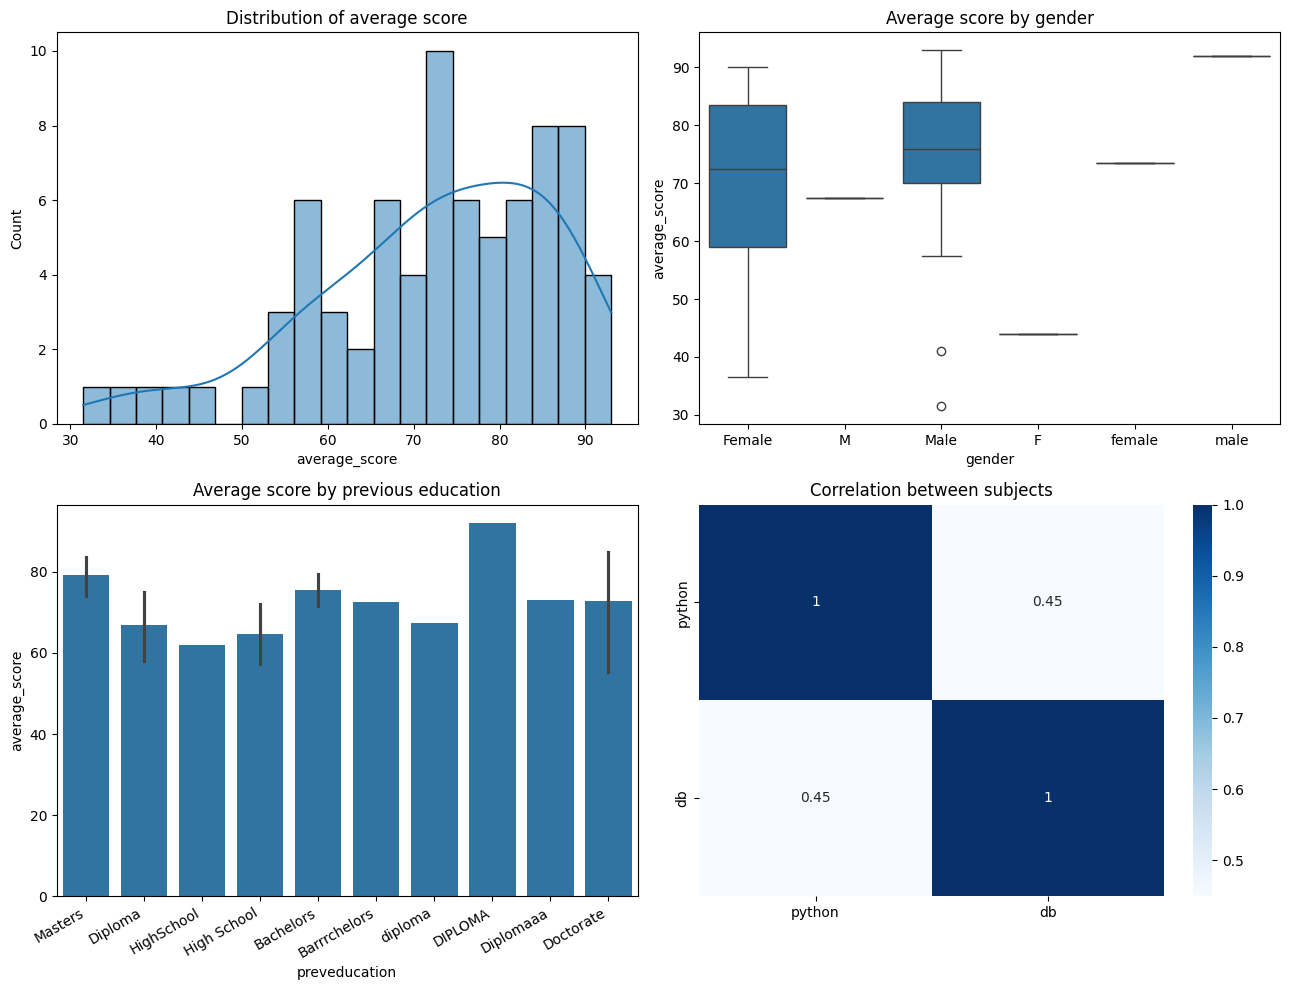

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(df['average_score'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of average score')

sns.boxplot(x='gender', y='average_score', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Average score by gender')

sns.barplot(x='preveducation', y='average_score', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Average score by previous education')
plt.setp(axes[1, 0].get_xticklabels(), rotation=30, ha='right')

sns.heatmap(df[subjects].corr(), annot=True, cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Correlation between subjects')

plt.tight_layout()
plt.savefig('student_analysis.png', dpi=150)
plt.show()

df.to_csv('students_cleaned.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/bi.csv', encoding='latin1')
df.columns = [c.strip().lower().replace(' ', '_').replace('/', '_') for c in df.columns]
print(df.shape)
print(df.columns.tolist())

(77, 11)
['fname', 'lname', 'age', 'gender', 'country', 'residence', 'entryexam', 'preveducation', 'studyhours', 'python', 'db']


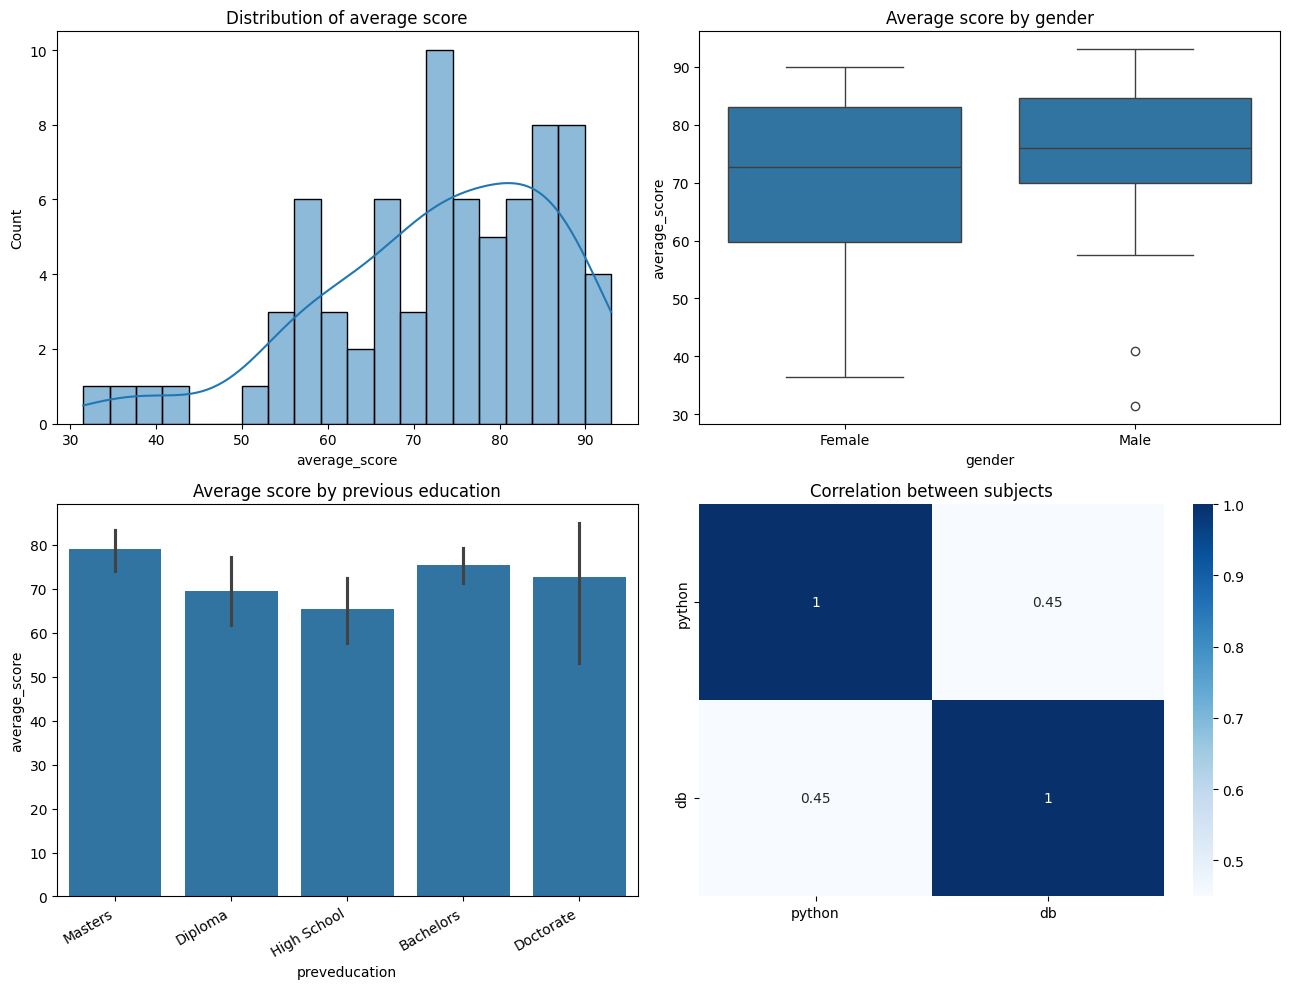

In [ ]:
subjects = ['python', 'db']
df['average_score'] = df[subjects].mean(axis=1).round(1)
df['result'] = np.where((df[subjects] >= 40).all(axis=1), 'Pass', 'Fail')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(df['average_score'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of average score')

sns.boxplot(x='gender', y='average_score', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Average score by gender')

sns.barplot(x='preveducation', y='average_score', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Average score by previous education')
plt.setp(axes[1, 0].get_xticklabels(), rotation=30, ha='right')

sns.heatmap(df[['python', 'db']].corr(), annot=True, cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Correlation between subjects')

plt.tight_layout()
plt.savefig('student_analysis.png', dpi=150)
plt.show()

df.drop(columns=['fname', 'lname']).to_csv('students_cleaned.csv', index=False)

In [ ]:
df['gender'] = df['gender'].str.strip().str.lower().map(
    {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'})

edu = df['preveducation'].str.strip().str.lower().str.replace(' ', '', regex=False)
df['preveducation'] = edu.map({
    'diploma': 'Diploma', 'diplomaaa': 'Diploma',
    'bachelors': 'Bachelors', 'barrrchelors': 'Bachelors',
    'masters': 'Masters', 'doctorate': 'Doctorate',
    'highschool': 'High School'})

print("Unmapped gender values:", df['gender'].isnull().sum())
print("Unmapped education values:", df['preveducation'].isnull().sum())

before = len(df)
df = df.dropna(subset=['python', 'db']).copy()
print("Rows dropped for missing scores:", before - len(df))

subjects = ['python', 'db']
df['average_score'] = df[subjects].mean(axis=1).round(1)
df['result'] = np.where((df[subjects] >= 40).all(axis=1), 'Pass', 'Fail')

print("Students:", len(df))
print("Pass rate (%):", round((df['result'] == 'Pass').mean() * 100, 1))

for col in ['gender', 'preveducation']:
    print(f"\nAverage score by {col}")
    print(df.groupby(col)['average_score'].agg(['mean', 'count']).round(1).sort_values('mean', ascending=False))

Unmapped gender values: 0
Unmapped education values: 0
Rows dropped for missing scores: 2
Students: 75
Pass rate (%): 93.3

Average score by gender
        mean  count
gender             
Male    75.3     33
Female  70.9     42

Average score by preveducation
               mean  count
preveducation             
Masters        79.1     16
Bachelors      75.4     25
Doctorate      72.7      5
Diploma        69.5     12
High School    65.4     17
